# 05 — Diagnostics

Comprehensive model diagnostics for the linear and logistic regression models.

**Linear model diagnostics:**
1. Residual plots (4-panel)
2. Formal tests: Breusch-Pagan, Shapiro-Wilk
3. VIF analysis
4. Cook's distance and DFBETAS
5. Robust regression comparison
6. Sensitivity analysis (exclude SKCM + UCEC)

**Logistic model diagnostics:**
7. Deviance and Pearson residuals
8. Standard vs Firth comparison

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats as sp_stats
from statsmodels.stats.diagnostic import het_breuschpagan

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import set_style, save_fig, plot_residual_diagnostics, plot_vif_bar
from src.stats import (
    fit_ols_formula, fit_robust_regression, compute_vif,
    extract_model_summary, cooks_distance, fit_firth_logistic,
)
from src.preprocessing import get_model_df

set_style()
FIGURES_DIR = PROJECT_ROOT / "figures"

df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "tmb_merged.parquet")
print(f"Loaded {df.shape[0]} samples")

Loaded 10953 samples


## 0. Refit Final Linear Model

In [2]:
predictors = ["age_at_diagnosis", "cancer_type", "sex",
              "aneuploidy_score", "fraction_genome_altered"]
available = [c for c in predictors if c in df.columns]
model_df = get_model_df(df, available, "log_tmb")
print(f"Complete cases: {len(model_df)}")

full_formula = "log_tmb ~ age_at_diagnosis + C(cancer_type) + C(sex) + aneuploidy_score + fraction_genome_altered"
m_full = fit_ols_formula(model_df, full_formula)
print(f"Full model adj R²: {m_full.rsquared_adj:.4f}")

Complete cases: 9568
Full model adj R²: 0.4456


## 1. Four-Panel Residual Diagnostics

  Saved: diagnostics_residuals_4panel.png, diagnostics_residuals_4panel.pdf


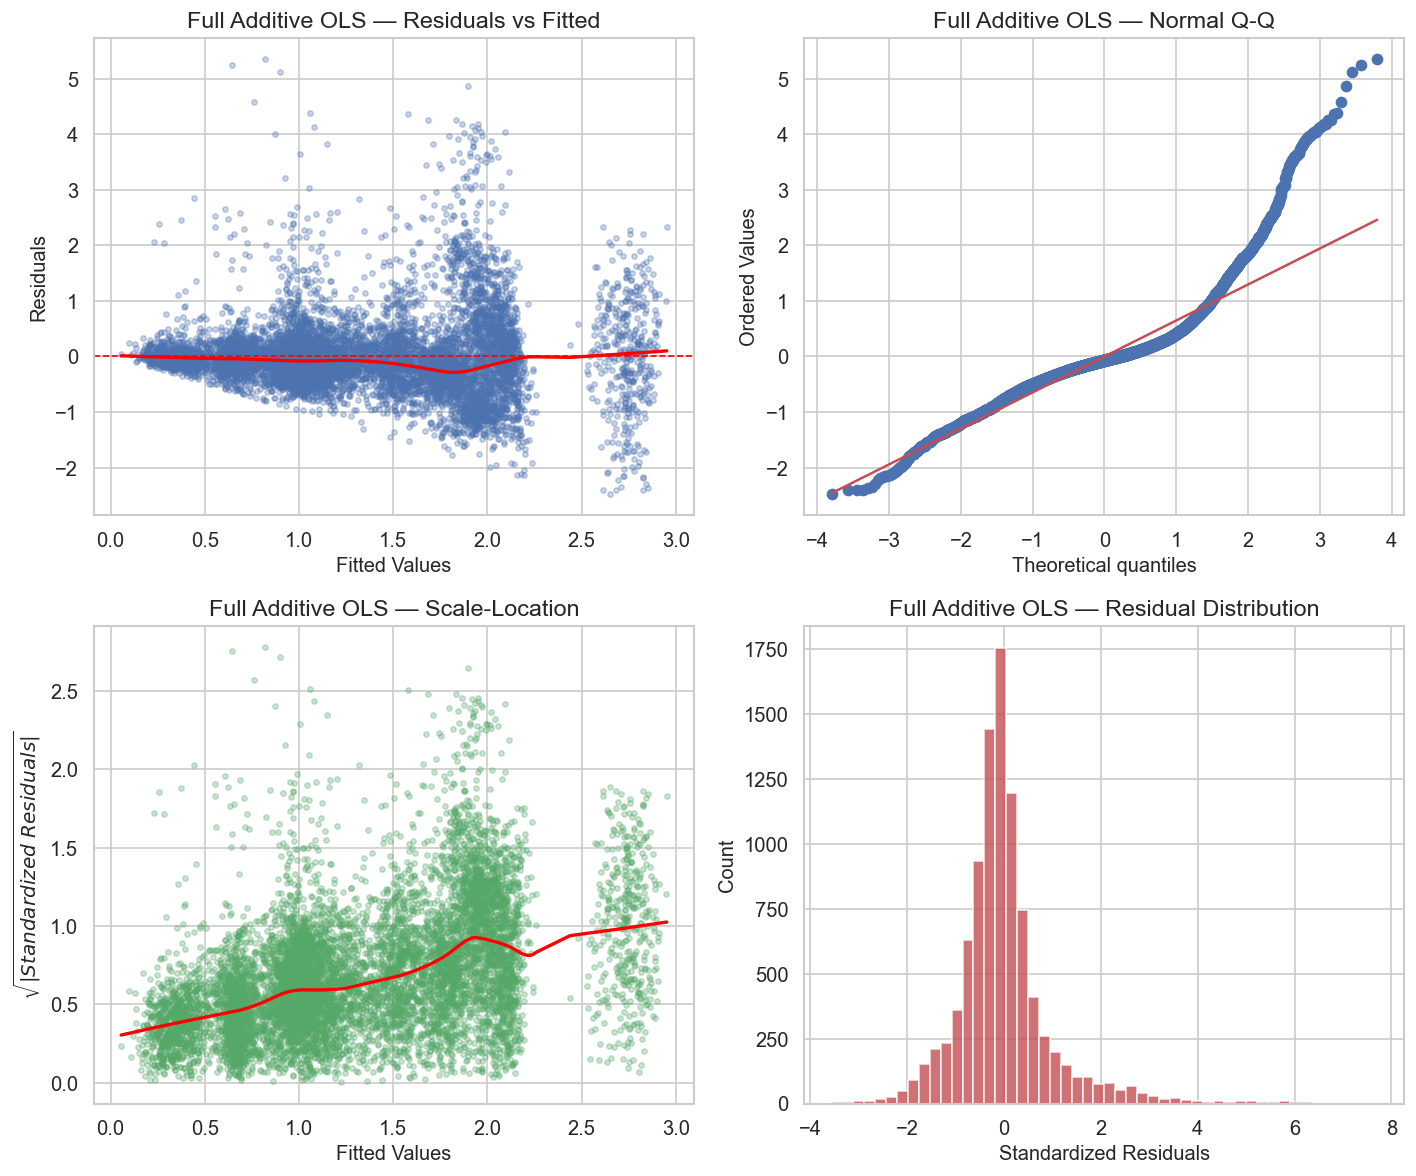

In [3]:
fig = plot_residual_diagnostics(
    m_full.fittedvalues.values,
    m_full.resid.values,
    model_name="Full Additive OLS",
)
save_fig(fig, "diagnostics_residuals_4panel", FIGURES_DIR)
plt.show()

## 2. Formal Tests

In [4]:
# Breusch-Pagan test for heteroscedasticity
bp_stat, bp_pval, bp_fstat, bp_fpval = het_breuschpagan(m_full.resid, m_full.model.exog)
print("=== Breusch-Pagan Test (Heteroscedasticity) ===")
print(f"  LM statistic: {bp_stat:.3f}")
print(f"  p-value:      {bp_pval:.2e}")
print(f"  F-statistic:  {bp_fstat:.3f}")
print(f"  F p-value:    {bp_fpval:.2e}")
print(f"  Conclusion:   {'Heteroscedasticity detected (p < 0.05)' if bp_pval < 0.05 else 'Homoscedasticity (p >= 0.05)'}")

=== Breusch-Pagan Test (Heteroscedasticity) ===
  LM statistic: 1215.554
  p-value:      3.09e-234
  F-statistic:  42.046
  F p-value:    1.39e-251
  Conclusion:   Heteroscedasticity detected (p < 0.05)


In [5]:
# Shapiro-Wilk test for normality of residuals
# Use a random subsample if n > 5000 (Shapiro-Wilk limit)
resids = m_full.resid.values
if len(resids) > 5000:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(resids), size=5000, replace=False)
    resids_sample = resids[sample_idx]
    print("(Using random subsample of 5000 for Shapiro-Wilk test)")
else:
    resids_sample = resids

sw_stat, sw_pval = sp_stats.shapiro(resids_sample)
print(f"\n=== Shapiro-Wilk Test (Normality) ===")
print(f"  W statistic: {sw_stat:.6f}")
print(f"  p-value:     {sw_pval:.2e}")
print(f"  Conclusion:  {'Non-normal residuals (p < 0.05)' if sw_pval < 0.05 else 'Normal residuals (p >= 0.05)'}")
print(f"\n  Note: With large samples, even small deviations from normality are detected.")
print(f"  Practically, OLS is robust to non-normality when n is large.")

(Using random subsample of 5000 for Shapiro-Wilk test)

=== Shapiro-Wilk Test (Normality) ===
  W statistic: 0.868546
  p-value:     6.35e-54
  Conclusion:  Non-normal residuals (p < 0.05)

  Note: With large samples, even small deviations from normality are detected.
  Practically, OLS is robust to non-normality when n is large.


## 3. VIF Analysis

Variance Inflation Factors:
               variable      VIF
       age_at_diagnosis 1.022937
       aneuploidy_score 1.852036
fraction_genome_altered 1.825122


  Saved: diagnostics_vif.png, diagnostics_vif.pdf


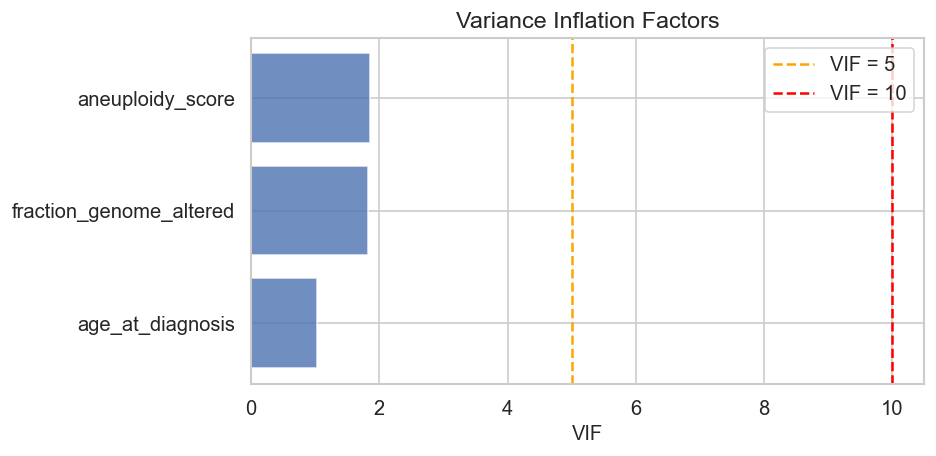


No multicollinearity concern (all VIF < 5).


In [6]:
numeric_predictors = ["age_at_diagnosis", "aneuploidy_score", "fraction_genome_altered"]
avail_num = [c for c in numeric_predictors if c in model_df.columns]

vif_df = compute_vif(model_df, avail_num)
print("Variance Inflation Factors:")
print(vif_df.to_string(index=False))

fig = plot_vif_bar(vif_df)
save_fig(fig, "diagnostics_vif", FIGURES_DIR)
plt.show()

high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\nConcern: {len(high_vif)} variable(s) with VIF > 5 — consider collinearity.")
    print("Aneuploidy score and FGA are biologically correlated (both measure genomic instability).")
else:
    print("\nNo multicollinearity concern (all VIF < 5).")

## 4. Cook's Distance

Cook's distance threshold (4/n): 0.000418
Influential observations: 352 / 9568 (3.7%)


  Saved: diagnostics_cooks_distance.png, diagnostics_cooks_distance.pdf


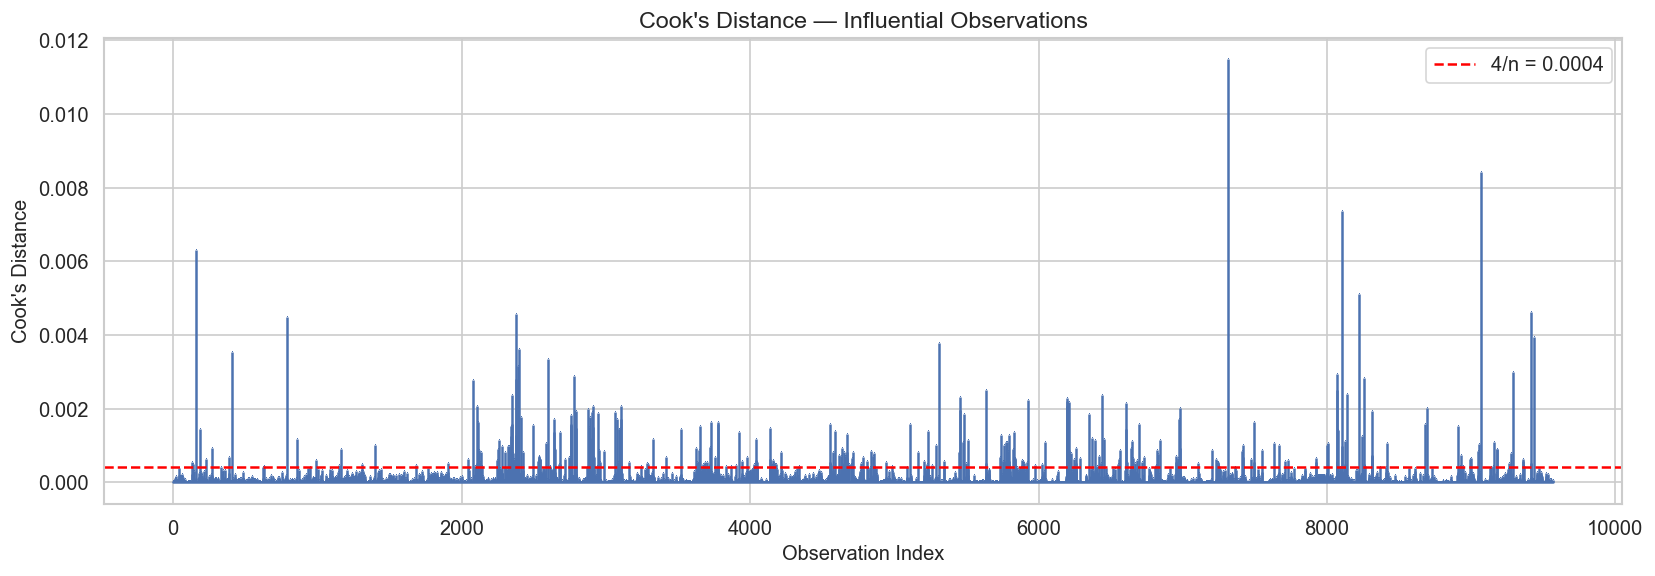

In [7]:
cooks_d = cooks_distance(m_full)
n = len(model_df)
p = m_full.df_model + 1
threshold = 4 / n

influential = cooks_d[cooks_d > threshold]
print(f"Cook's distance threshold (4/n): {threshold:.6f}")
print(f"Influential observations: {len(influential)} / {n} ({len(influential)/n:.1%})")

# Plot Cook's distance
fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(range(n), cooks_d, markerfmt=",", linefmt="C0-", basefmt="C0-")
ax.axhline(threshold, color="red", ls="--", lw=1.5, label=f"4/n = {threshold:.4f}")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance — Influential Observations")
ax.legend()
fig.tight_layout()
save_fig(fig, "diagnostics_cooks_distance", FIGURES_DIR)
plt.show()

In [8]:
# Characterize influential observations by cancer type
if "cancer_type" in model_df.columns:
    model_df_with_cooks = model_df.copy()
    model_df_with_cooks["cooks_d"] = cooks_d.values
    model_df_with_cooks["influential"] = cooks_d.values > threshold
    
    infl_by_ct = (
        model_df_with_cooks.groupby("cancer_type")["influential"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "n_influential", "count": "n_total"})
    )
    infl_by_ct["pct_influential"] = (infl_by_ct["n_influential"] / infl_by_ct["n_total"] * 100).round(1)
    infl_by_ct = infl_by_ct.sort_values("pct_influential", ascending=False)
    print("Top 10 cancer types by proportion of influential observations:")
    print(infl_by_ct.head(10).to_string())

Top 10 cancer types by proportion of influential observations:
                          n_influential  n_total  pct_influential
cancer_type                                                      
Mature B-Cell Neoplasms               7       37             18.9
Melanoma                             64      421             15.2
Colorectal Cancer                    60      512             11.7
Adrenocortical Carcinoma             10       89             11.2
Endometrial Cancer                   60      553             10.8
Esophagogastric Cancer               43      581              7.4
Cervical Cancer                      17      278              6.1
Sarcoma                              13      227              5.7
Leukemia                              7      123              5.7
Cholangiocarcinoma                    2       36              5.6


## 5. DFBETAS for Key Coefficients

  Saved: diagnostics_dfbetas_age.png, diagnostics_dfbetas_age.pdf


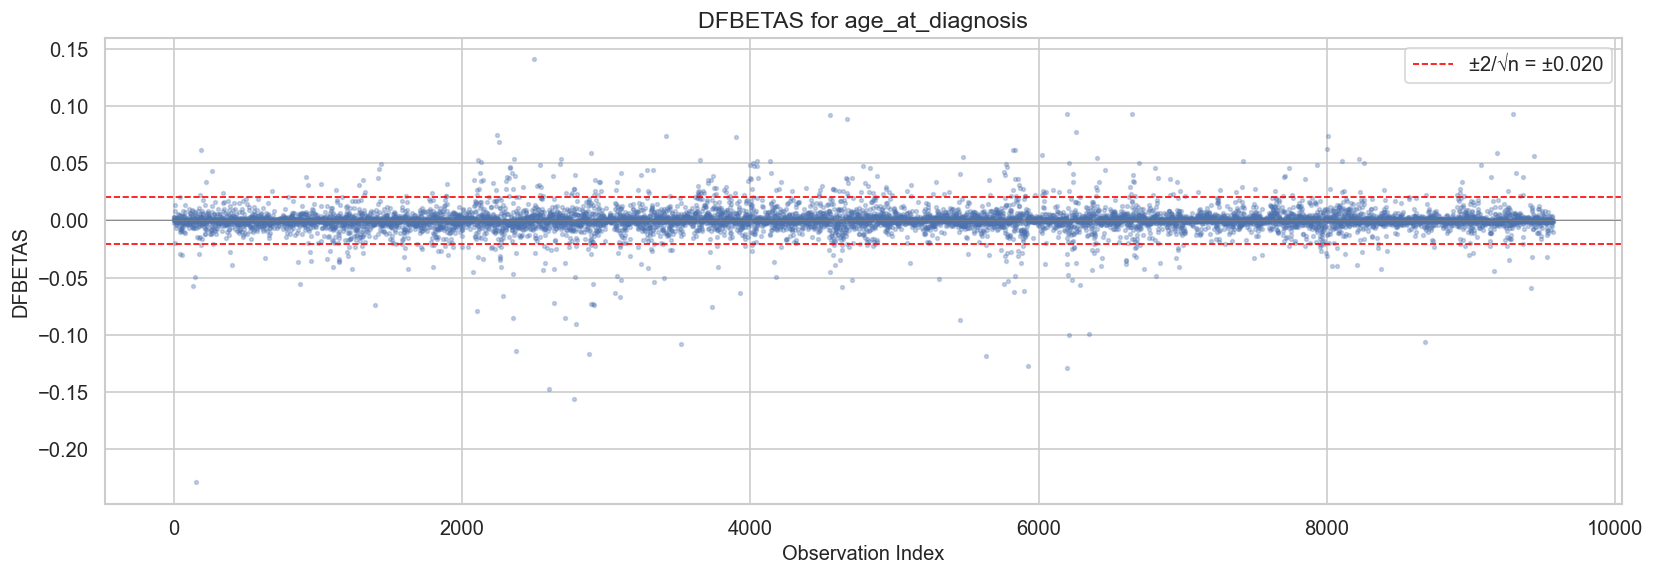

Observations with |DFBETAS| > threshold for age: 495 (5.2%)


In [9]:
influence = m_full.get_influence()
dfbetas = influence.dfbetas
dfbetas_threshold = 2 / np.sqrt(n)

# Focus on age coefficient (typically index 1 after intercept)
param_names = m_full.params.index.tolist()
age_idx = None
for i, name in enumerate(param_names):
    if "age" in name.lower():
        age_idx = i
        break

if age_idx is not None:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.scatter(range(n), dfbetas[:, age_idx], alpha=0.3, s=5)
    ax.axhline(dfbetas_threshold, color="red", ls="--", lw=1, label=f"±2/√n = ±{dfbetas_threshold:.3f}")
    ax.axhline(-dfbetas_threshold, color="red", ls="--", lw=1)
    ax.axhline(0, color="grey", ls="-", lw=0.5)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("DFBETAS")
    ax.set_title(f"DFBETAS for {param_names[age_idx]}")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "diagnostics_dfbetas_age", FIGURES_DIR)
    plt.show()
    
    n_influential_age = np.sum(np.abs(dfbetas[:, age_idx]) > dfbetas_threshold)
    print(f"Observations with |DFBETAS| > threshold for age: {n_influential_age} ({n_influential_age/n:.1%})")

## 6. Robust Regression (Huber M-estimator)

In [10]:
m_robust = fit_robust_regression(model_df, full_formula, m_estimator="huber")

# Compare OLS vs robust coefficients
ols_coef = extract_model_summary(m_full)
robust_coef = extract_model_summary(m_robust)

# Non-cancer-type comparison
ols_non_ct = ols_coef[~ols_coef["variable"].str.startswith("C(cancer_type")]
robust_non_ct = robust_coef[~robust_coef["variable"].str.startswith("C(cancer_type")]

comparison = ols_non_ct[["variable", "coef"]].merge(
    robust_non_ct[["variable", "coef"]],
    on="variable",
    suffixes=("_OLS", "_Robust"),
)
comparison["diff"] = comparison["coef_OLS"] - comparison["coef_Robust"]
# Handle division by zero for near-zero coefficients
comparison["pct_diff"] = np.where(
    comparison["coef_OLS"].abs() > 1e-10,
    ((comparison["diff"] / comparison["coef_OLS"]) * 100).round(1),
    0.0,
)

print("OLS vs Robust (Huber) coefficients:")
print(comparison.to_string(index=False))
print(f"\nLarge differences suggest influential outliers are affecting OLS estimates.")

OLS vs Robust (Huber) coefficients:
               variable  coef_OLS  coef_Robust      diff  pct_diff
              Intercept  0.712497     0.327649  0.384848      54.0
         C(sex)[T.MALE]  0.029631     0.027053  0.002578       8.7
       age_at_diagnosis  0.005163     0.005763 -0.000600     -11.6
       aneuploidy_score -0.003564     0.001679 -0.005243     147.1
fraction_genome_altered -0.053139     0.127677 -0.180816     340.3

Large differences suggest influential outliers are affecting OLS estimates.


## 7. Sensitivity Analysis: Exclude SKCM + UCEC

In [11]:
if "cancer_type" in model_df.columns:
    # Identify SKCM and UCEC (may appear as full names or abbreviations)
    exclude_types = []
    for ct in model_df["cancer_type"].unique():
        ct_lower = str(ct).lower()
        if any(term in ct_lower for term in ["skcm", "melanoma", "ucec", "endometrial", "uterine corpus"]):
            exclude_types.append(ct)
    
    if exclude_types:
        print(f"Excluding: {exclude_types}")
        sens_df = model_df[~model_df["cancer_type"].isin(exclude_types)].copy()
        print(f"Samples remaining: {len(sens_df)} (removed {len(model_df) - len(sens_df)})")
        
        m_sens = fit_ols_formula(sens_df, full_formula)
        
        print(f"\nFull dataset adj R²:      {m_full.rsquared_adj:.4f}")
        print(f"Without SKCM/UCEC adj R²: {m_sens.rsquared_adj:.4f}")
        
        # Compare key coefficients
        sens_coef = extract_model_summary(m_sens)
        sens_non_ct = sens_coef[~sens_coef["variable"].str.startswith("C(cancer_type")]
        
        sens_comparison = ols_non_ct[["variable", "coef"]].merge(
            sens_non_ct[["variable", "coef"]],
            on="variable",
            suffixes=("_full", "_sensitivity"),
        )
        print("\nCoefficient stability (full vs sensitivity):")
        print(sens_comparison.to_string(index=False))
    else:
        print("Could not identify SKCM/UCEC cancer types in the data.")
        print(f"Available types: {sorted(model_df['cancer_type'].unique())}")

Excluding: ['Endometrial Cancer', 'Melanoma', 'Ocular Melanoma']
Samples remaining: 8514 (removed 1054)

Full dataset adj R²:      0.4456
Without SKCM/UCEC adj R²: 0.4560

Coefficient stability (full vs sensitivity):
               variable  coef_full  coef_sensitivity
              Intercept   0.712497          0.477375
         C(sex)[T.MALE]   0.029631          0.008483
       age_at_diagnosis   0.005163          0.006524
       aneuploidy_score  -0.003564         -0.001542
fraction_genome_altered  -0.053139          0.192216


## 8. Logistic Model Diagnostics

  Saved: diagnostics_logistic_residuals.png, diagnostics_logistic_residuals.pdf


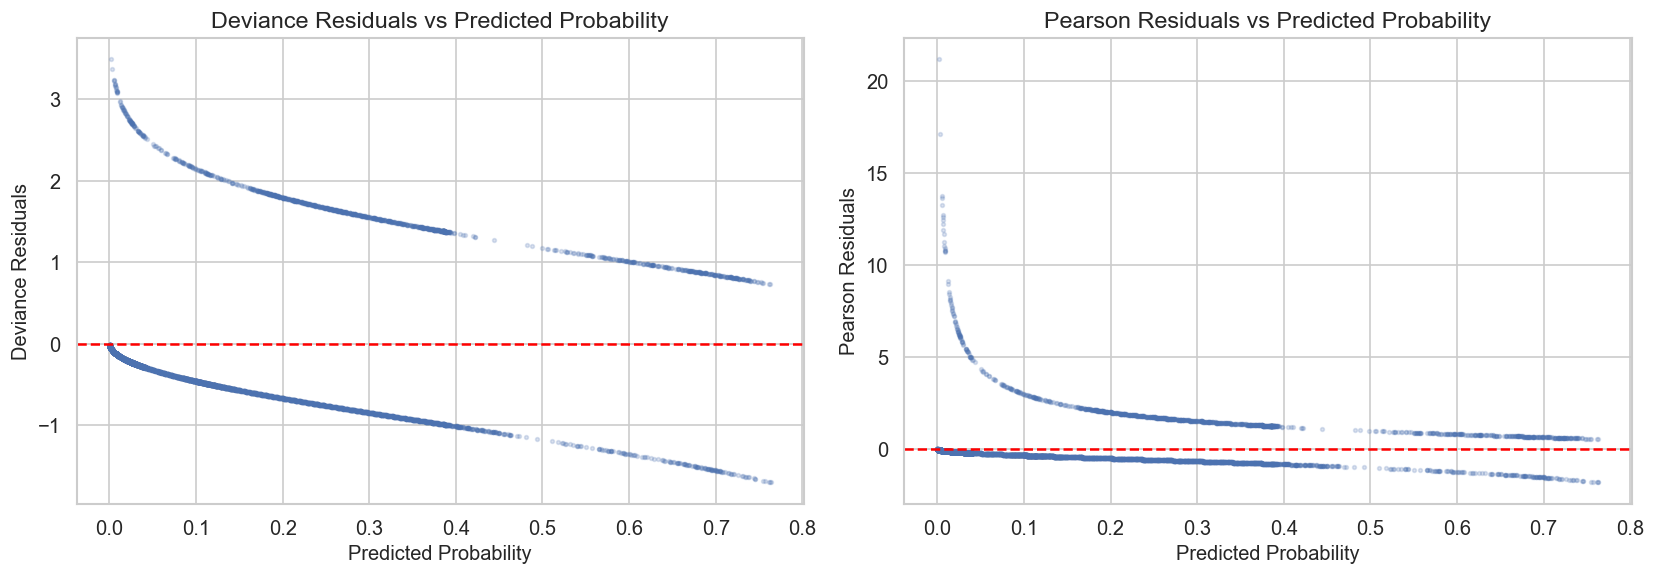

In [12]:
# Refit logistic model
logit_df = get_model_df(df, available, "tmb_high")
logit_formula = "tmb_high ~ age_at_diagnosis + C(cancer_type) + C(sex) + aneuploidy_score + fraction_genome_altered"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Use BFGS — Newton fails due to quasi-complete separation
    logit_result = sm.Logit.from_formula(logit_formula, data=logit_df).fit(method="bfgs", disp=0, maxiter=200)

# Deviance residuals
y_true = logit_df["tmb_high"].values
y_prob = logit_result.predict(logit_df).values

deviance_resid = np.sign(y_true - y_prob) * np.sqrt(
    -2 * (y_true * np.log(np.clip(y_prob, 1e-10, 1)) +
           (1 - y_true) * np.log(np.clip(1 - y_prob, 1e-10, 1)))
)

# Pearson residuals
pearson_resid = (y_true - y_prob) / np.sqrt(np.clip(y_prob * (1 - y_prob), 1e-10, None))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_prob, deviance_resid, alpha=0.2, s=5)
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Deviance Residuals")
axes[0].set_title("Deviance Residuals vs Predicted Probability")

axes[1].scatter(y_prob, pearson_resid, alpha=0.2, s=5)
axes[1].axhline(0, color="red", ls="--")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Pearson Residuals")
axes[1].set_title("Pearson Residuals vs Predicted Probability")

fig.tight_layout()
save_fig(fig, "diagnostics_logistic_residuals", FIGURES_DIR)
plt.show()

In [13]:
# Standard vs Firth comparison
cat_cols = [c for c in ["cancer_type", "sex"] if c in logit_df.columns]
X_firth = pd.get_dummies(logit_df[available], columns=cat_cols, drop_first=True)
X_firth = X_firth.apply(pd.to_numeric, errors="coerce").dropna(axis=1)
y_firth = logit_df.loc[X_firth.index, "tmb_high"].astype(int)

firth_result = fit_firth_logistic(X_firth, y_firth)

std_coefs = extract_model_summary(logit_result)
std_non_ct = std_coefs[~std_coefs["variable"].str.contains("cancer_type", case=False)]

firth_df = pd.DataFrame({
    "variable": firth_result["feature_names"],
    "coef_firth": firth_result["coef"].flatten(),
})
firth_non_ct = firth_df[~firth_df["variable"].str.contains("cancer_type", case=False)]

print("Standard vs Firth coefficient comparison (non-cancer-type):")
print("\nStandard logistic:")
print(std_non_ct[["variable", "coef"]].to_string(index=False))
print("\nFirth logistic:")
print(firth_non_ct.to_string(index=False))
print("\nFirth coefficients should be shrunk toward zero relative to standard logistic,")
print("especially for variables involved in quasi-complete separation.")

Standard vs Firth coefficient comparison (non-cancer-type):

Standard logistic:
               variable      coef
              Intercept -2.958241
         C(sex)[T.MALE]  0.062856
       age_at_diagnosis  0.001020
       aneuploidy_score -0.024285
fraction_genome_altered -0.652224

Firth logistic:
               variable  coef_firth
       age_at_diagnosis    0.001173
       aneuploidy_score   -0.024287
fraction_genome_altered   -0.664333
               sex_MALE    0.065443

Firth coefficients should be shrunk toward zero relative to standard logistic,
especially for variables involved in quasi-complete separation.


## 9. Diagnostic Summary

In [14]:
summary_data = {
    "Diagnostic Test": [
        "Breusch-Pagan (heteroscedasticity)",
        "Shapiro-Wilk (normality)",
        "VIF (multicollinearity)",
        "Cook's distance (influence)",
        "Robust vs OLS comparison",
        "Sensitivity (excl. SKCM/UCEC)",
    ],
    "Result": [
        f"LM = {bp_stat:.1f}, p = {bp_pval:.2e}",
        f"W = {sw_stat:.4f}, p = {sw_pval:.2e}",
        f"Max VIF = {vif_df['VIF'].max():.2f}",
        f"{len(influential)} influential obs ({len(influential)/n:.1%})",
        "See coefficient comparison above",
        "See coefficient comparison above",
    ],
    "Implication": [
        "Heteroscedasticity detected" if bp_pval < 0.05 else "Homoscedastic",
        "Non-normal (expected with large n)" if sw_pval < 0.05 else "Normal",
        "Collinearity concern" if vif_df['VIF'].max() > 5 else "No concern",
        "Review high-TMB cancer types",
        "Outlier sensitivity check",
        "Coefficient stability check",
    ],
}

summary_table = pd.DataFrame(summary_data)
summary_table.style.set_properties(**{"text-align": "left"})

,Diagnostic Test,Result,Implication
0,Breusch-Pagan (heteroscedasticity),"LM = 1215.6, p = 3.09e-234",Heteroscedasticity detected
1,Shapiro-Wilk (normality),"W = 0.8685, p = 6.35e-54",Non-normal (expected with large n)
2,VIF (multicollinearity),Max VIF = 1.85,No concern
3,Cook's distance (influence),352 influential obs (3.7%),Review high-TMB cancer types
4,Robust vs OLS comparison,See coefficient comparison above,Outlier sensitivity check
5,Sensitivity (excl. SKCM/UCEC),See coefficient comparison above,Coefficient stability check
